# V3 moneyness performance — 1.5-year monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_1p5y_monthly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 601` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1.5-year lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_monthly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,8,30,72,34,6,150
2013-2014,0,5,142,3,0,150
2018-2019,0,4,140,7,0,151
2019-2020,0,6,139,5,0,150
All,8,45,493,49,6,601


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 8  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,8,40.40,0.9541,+0.1029,+17.93,22.3%,
GARCH,8,39.58,1.0074,+1.0074,+31.78,19.4%,
Heston,8,28.18,0.8867,+0.8250,+22.79,24.0%,BEST
Merton,8,41.10,1.0019,+0.1650,+19.26,19.1%,
GARCH–Merton,8,51.18,1.5433,+1.5433,+44.92,22.2%,
Heston–Merton,8,28.99,0.9355,+0.9355,+23.63,20.6%,


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 45  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,45,67.36,1.7884,+0.9067,+36.61,23.8%,
GARCH,45,72.16,1.8679,+1.5644,+48.95,28.8%,
Heston,45,37.80,1.1721,+0.7247,+23.43,25.0%,BEST
Merton,45,64.91,1.7235,+0.8110,+34.40,20.3%,
GARCH–Merton,45,86.75,2.3155,+2.0820,+66.51,27.6%,
Heston–Merton,45,38.86,1.1694,+0.6418,+22.94,19.8%,


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 493  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,493,51.70,2.0852,+1.3903,+34.04,27.1%,
GARCH,493,60.35,2.2439,+1.9522,+41.43,30.0%,
Heston,493,48.25,2.0136,+1.6772,+35.44,28.5%,BEST
Merton,493,48.60,1.9618,+1.2343,+31.00,23.4%,
GARCH–Merton,493,70.31,2.7868,+2.5402,+53.33,27.6%,
Heston–Merton,493,50.83,1.9345,+1.5683,+34.48,22.2%,


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 49  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,49,41.26,1.4788,+0.7388,+18.69,28.6%,
GARCH,49,60.12,1.6708,+1.5690,+47.39,34.5%,
Heston,49,30.37,1.2322,+0.8185,+16.27,31.2%,BEST
Merton,49,38.91,1.3524,+0.6219,+16.37,24.9%,
GARCH–Merton,49,69.76,2.0516,+1.9321,+57.33,30.9%,
Heston–Merton,49,30.97,1.1431,+0.7327,+15.98,24.7%,


### Table M5. DITM  ·  m > 1.02  ·  n = 6  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,6,41.39,0.7738,-0.1103,+19.62,27.5%,
GARCH,6,77.41,2.4455,+2.4455,+64.89,28.8%,
Heston,6,17.20,0.3569,+0.2325,+9.70,31.5%,BEST
Merton,6,38.41,0.7773,-0.1722,+16.39,23.9%,
GARCH–Merton,6,86.27,2.9468,+2.9468,+73.23,21.2%,
Heston–Merton,6,17.83,0.3554,+0.3296,+11.51,22.5%,


### Figure M1 — Model × Moneyness RMSE% heatmap


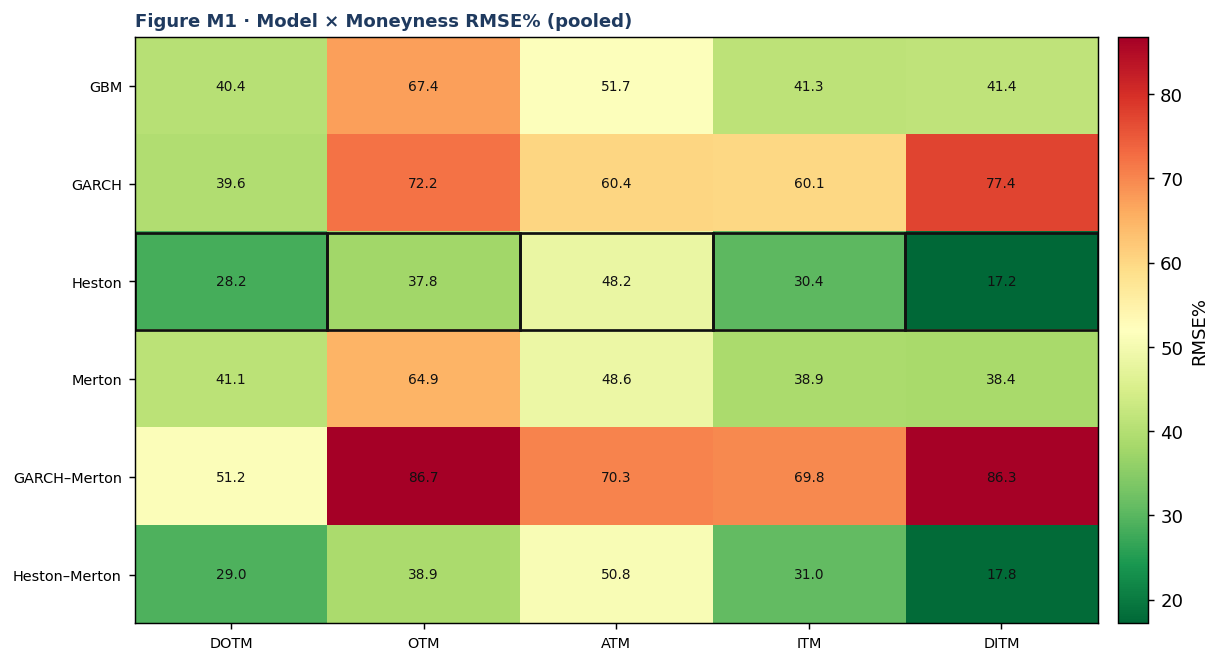

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


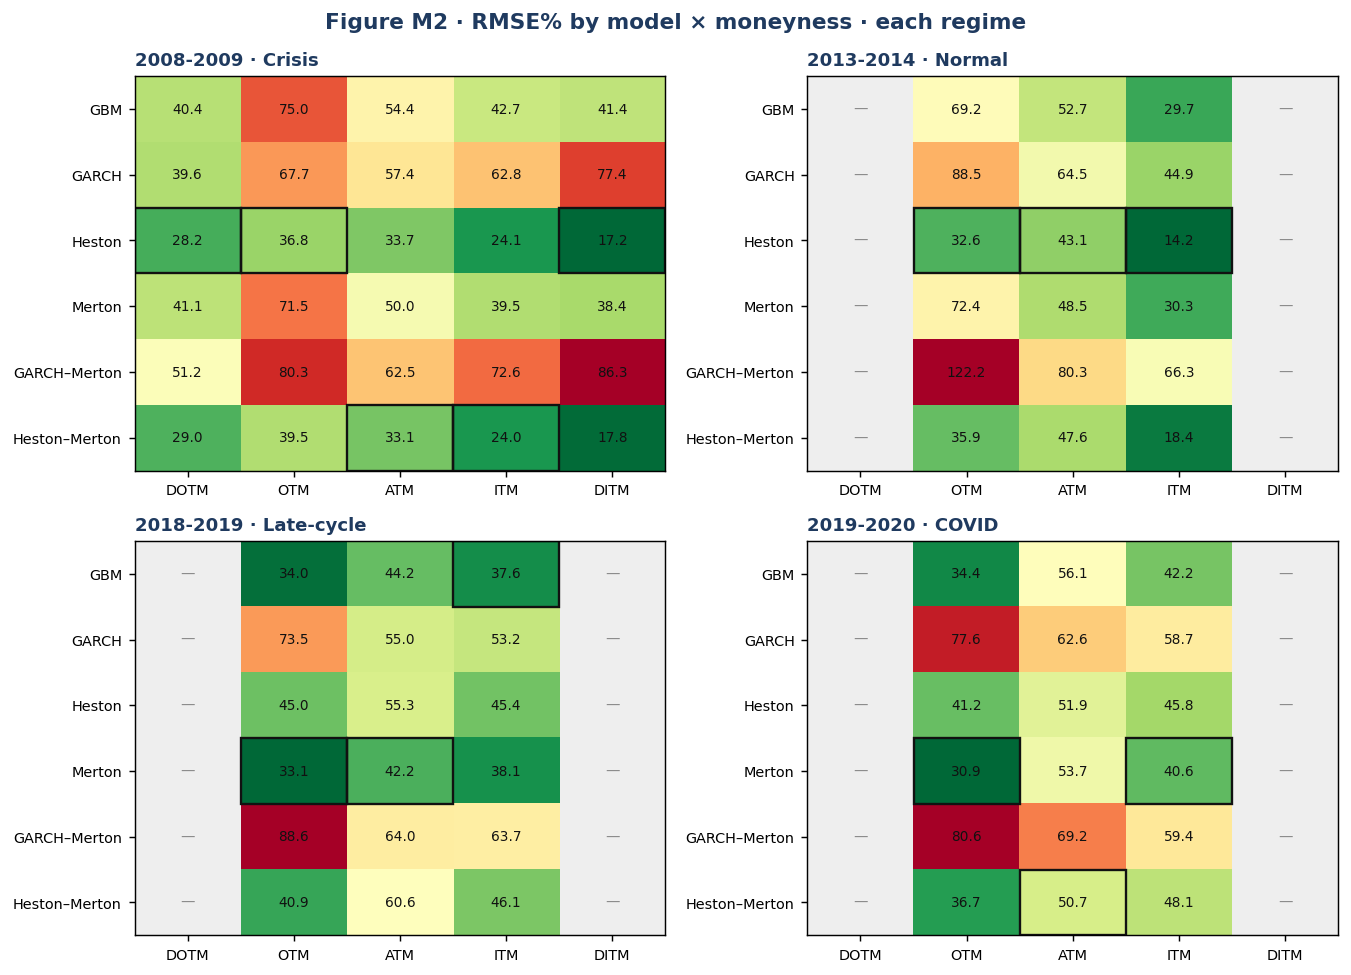

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Heston,Heston,Heston–Merton,Heston–Merton,Heston
2013-2014,—,Heston,Heston,Heston,—
2018-2019,—,Merton,Merton,GBM,—
2019-2020,—,Merton,Heston–Merton,Merton,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,8,30,72,34,6
2013-2014,0,5,142,3,0
2018-2019,0,4,140,7,0
2019-2020,0,6,139,5,0


## 4. Findings

- DOTM (n = 8): BEST = Heston with RMSE% = 28.18, Bias% = +22.79.

- OTM (n = 45): BEST = Heston with RMSE% = 37.80, Bias% = +23.43.

- ATM (n = 493): BEST = Heston with RMSE% = 48.25, Bias% = +35.44.

- ITM (n = 49): BEST = Heston with RMSE% = 30.37, Bias% = +16.27.

- DITM (n = 6): BEST = Heston with RMSE% = 17.20, Bias% = +9.70.

- Overall, the moneyness ranking is stable: Heston is BEST in every non-empty bucket.

- Inside regimes, the BEST model also changes with moneyness in: 2008-2009, 2018-2019, 2019-2020.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v3_1p5y_monthly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_1p5y_monthly/contracts/`.
